In [1]:
import numpy as np
import xarray as xr
from scipy.ndimage import uniform_filter

#########################################
# 1) Ouvrir le dataset (à adapter)
#########################################

ds = xr.open_dataset('/home/vdemeyer/projects/rrg-gachon/vdemeyer/UBI/PSL/psl_ubi_203004_se.nc')
ds['time'] = ds['time'].dt.round('h')
var = ds["psl"]                          # <<< variable à analyser

###############################################################
# 2) Calcul de l'aire (en m²) pour chaque cellule (rlat, rlon)
###############################################################

# Rayon terrestre en mètres
Re = 6371000  

# Conversion en radians
lat = np.deg2rad(ds.lat)
lon = np.deg2rad(ds.lon)

# On suppose que la grille est régulière en indices
# → on approxime d(lat), d(lon) via différences locales
dlat = np.abs(np.gradient(lat, axis=0))
dlon = np.abs(np.gradient(lon, axis=1))

# Formule CF conventionnelle pour aire d'une cellule lat-lon
# area = R² * cos(lat) * dlat * dlon
cell_area = (Re**2) * np.cos(lat) * dlat * dlon

# cell_area → DataArray aligné en (rlat, rlon)
cell_area = xr.DataArray(cell_area, coords={"rlat": ds.rlat, "rlon": ds.rlon})

###############################################################
# 3) Vérifier variation d’aire (clé pour savoir si uniform_filter est OK)
###############################################################

area_min = float(cell_area.min())
area_max = float(cell_area.max())
ratio = area_max / area_min

print(f"\nAire min  = {area_min: .3e} m²")
print(f"Aire max  = {area_max: .3e} m²")
print(f"Ratio max/min = {ratio: .3f}")

if ratio <= 1.1:
    print("✅ Grille quasi uniforme → uniform_filter acceptable.")
elif ratio <= 1.5:
    print("⚠️ Variation significative → uniform_filter possible mais avec prudence.")
else:
    print("❌ Grille très non uniforme → uniform_filter NON recommandé.")

# ###############################################################
# # 4) Test (optionnel) : est-ce que uniform_filter conserve l'intégrale ?
# ###############################################################

# # Application du filtre (ex : fenêtre 5×5)
# filtered = xr.apply_ufunc(
#     uniform_filter,
#     var,
#     kwargs={"size": 5},  # <<< taille du filtre en indices
#     dask="allowed"
# )

# # Calcul de l'intégrale avant / après (pondérée par l'aire)
# integral_before = float((var.mean(dim="time") * cell_area).sum())
# integral_after  = float((filtered.mean(dim="time") * cell_area).sum())

# print("\nTest de conservation avec pondération par aire :")
# print(f"Intégrale avant filtre : {integral_before:.3e}")
# print(f"Intégrale après filtre  : {integral_after:.3e}")
# print(f"Δ relatif = {(integral_after - integral_before)/integral_before:.3%}")



Aire min  =  1.678e+07 m²
Aire max  =  4.862e+10 m²
Ratio max/min =  2898.061
❌ Grille très non uniforme → uniform_filter NON recommandé.

Test de conservation avec pondération par aire :
Intégrale avant filtre : 5.172e+18
Intégrale après filtre  : 5.172e+18
Δ relatif = -0.000%


In [12]:
area

array([[1.04203017e+08, 1.04279789e+08, 1.04394442e+08, ...,
        9.54327705e+07, 9.52856035e+07, 9.51930577e+07],
       [1.04327542e+08, 1.04413699e+08, 1.04528269e+08, ...,
        9.55449439e+07, 9.54344803e+07, 9.53601665e+07],
       [1.04468362e+08, 1.04535278e+08, 1.04640540e+08, ...,
        9.56731227e+07, 9.55445308e+07, 9.54521028e+07],
       ...,
       [1.74705503e+07, 1.74535797e+07, 1.74614541e+07, ...,
        1.77272276e+07, 1.77435172e+07, 1.77761058e+07],
       [1.71279296e+07, 1.71050789e+07, 1.71131692e+07, ...,
        1.74494279e+07, 1.74653332e+07, 1.74981918e+07],
       [1.68619492e+07, 1.68381576e+07, 1.68481027e+07, ...,
        1.72353952e+07, 1.72517318e+07, 1.72841535e+07]])

Text(0, 0.5, 'Latitude')

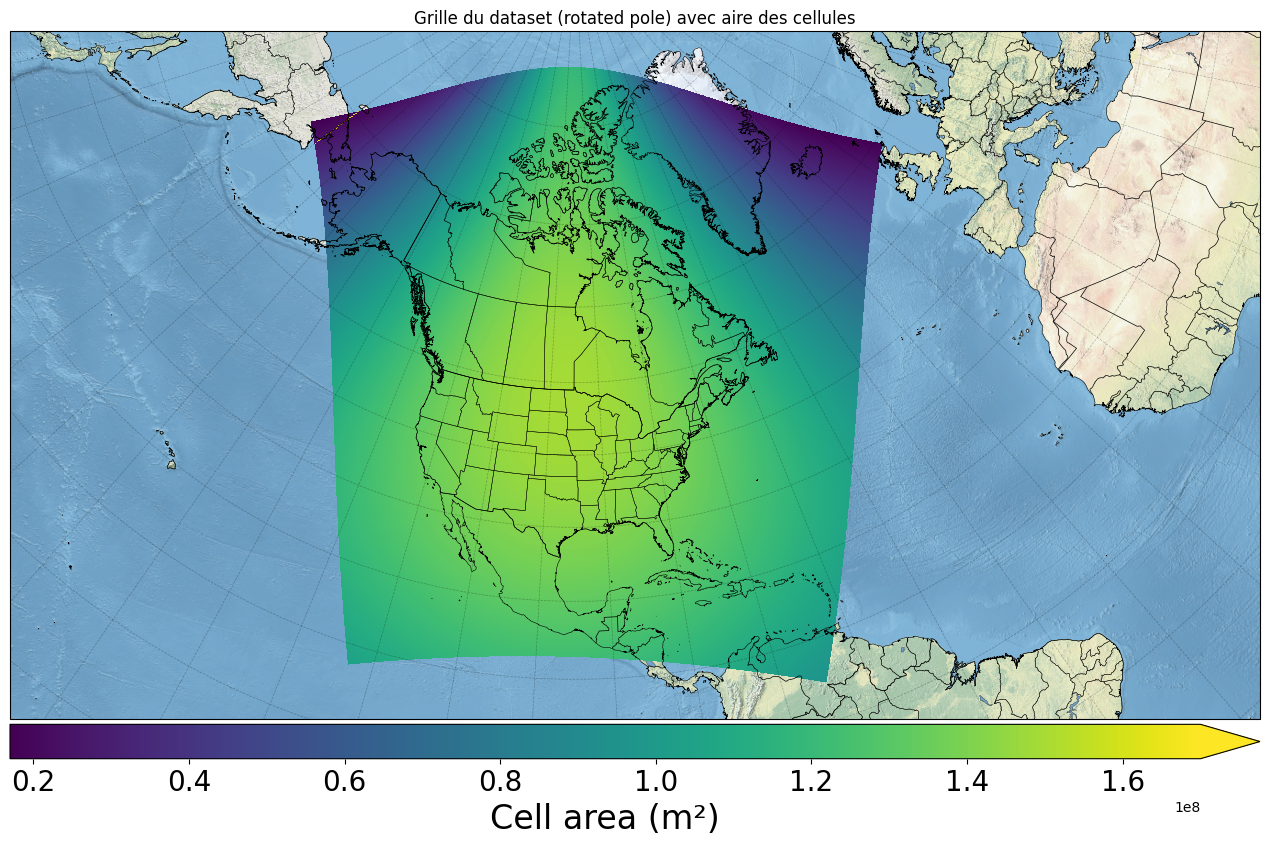

In [19]:
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt

lat2d = ds["lat"].values   # shape (rlat, rlon)
lon2d = ds["lon"].values

Re = 6371000
lat_r = np.deg2rad(lat2d)
lon_r = np.deg2rad(lon2d)
dlat = np.abs(np.gradient(lat_r, axis=0))
dlon = np.abs(np.gradient(lon_r, axis=1))
area = (Re**2) * np.cos(lat_r) * dlat * dlon

pole_lon = ds.rotated_pole.attrs['grid_north_pole_longitude']
pole_lat = ds.rotated_pole.attrs['grid_north_pole_latitude']

plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(12.5,12.5), tight_layout = {'pad': 0})

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

ax.set_extent([-170, 5, 80, 5], crs=ccrs.PlateCarree())

borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())


# Affichage de la grille colorée par aire
mesh = ax.pcolormesh(lon2d, lat2d, area, shading="auto", cmap="viridis", vmin=1.7e7, vmax=1.7e8, transform=ccrs.PlateCarree())

cb = fig.colorbar(mesh, cax=cax, orientation="horizontal", pad=0.02, aspect=40, extend='max')
cb.ax.tick_params(labelsize=20)
cb.set_label("Cell area (m²)", fontsize=24)

ax.set_title("Grille du dataset (rotated pole) avec aire des cellules")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

Text(0, 0.5, 'Latitude')

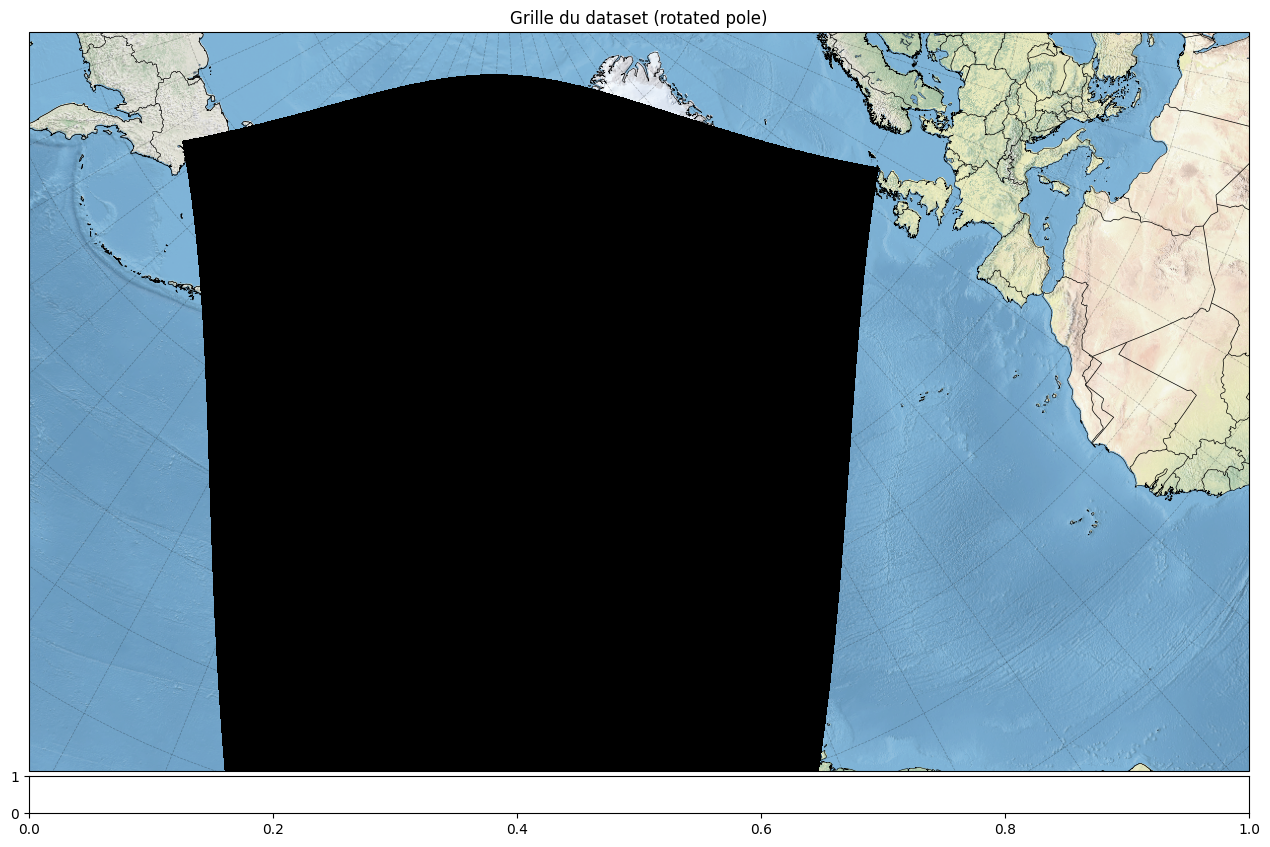

In [27]:
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt

lat2d = ds["lat"].values   # shape (rlat, rlon)
lon2d = ds["lon"].values

Re = 6371000
lat_r = np.deg2rad(lat2d)
lon_r = np.deg2rad(lon2d)
dlat = np.abs(np.gradient(lat_r, axis=0))
dlon = np.abs(np.gradient(lon_r, axis=1))
area = (Re**2) * np.cos(lat_r) * dlat * dlon

pole_lon = ds.rotated_pole.attrs['grid_north_pole_longitude']
pole_lat = ds.rotated_pole.attrs['grid_north_pole_latitude']

plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(12.5,12.5), tight_layout = {'pad': 0})

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

ax.set_extent([-150, 5, 80, 15], crs=ccrs.PlateCarree())

borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())


# Affichage de la grille colorée par aire

dummy = np.full_like(lat2d, np.nan)
ax.pcolormesh(lon2d, lat2d, dummy, edgecolor='black', facecolor='none', linewidth=0.005, transform=ccrs.PlateCarree())
    
# cb = fig.colorbar(mesh, cax=cax, orientation="horizontal", pad=0.02, aspect=40, extend='max')
# cb.ax.tick_params(labelsize=20)
# cb.set_label("Cell area (m²)", fontsize=24)

ax.set_title("Grille du dataset (rotated pole)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")